# Notebook C8 — Export du modèle & Analyse SHAP

**Objectif** : Valider la compétence C8 du référentiel RNCP37827

Ce notebook fait deux choses :
1. **Export `.pkl`** — sauvegarder le modèle XGBoost entraîné dans un fichier réutilisable
2. **Analyse SHAP** — expliquer pourquoi le modèle prédit tel ou tel prix

**Modèle utilisé** : XGBoost (meilleur du benchmark C7 — R²=0.9755, RMSE=0.0886)

**Dataset** : `fruits_legumes_enrichi.csv` — 710 lignes, 12 features

## 1. Imports et chargement des données

In [2]:
# ── Bibliothèques de base ──
import pandas as pd                          # Manipulation des données
import numpy as np                           # Calculs numériques
import matplotlib.pyplot as plt              # Graphiques
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from xgboost import XGBRegressor             # Notre modèle retenu
from sklearn.model_selection import train_test_split  # Séparation train/test
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Export du modèle ──
import joblib                                # Pour sauvegarder le modèle en .pkl
import os                                    # Pour créer des dossiers

# ── SHAP — interprétabilité ──
import shap                                  # Pour expliquer les prédictions

print('✅ Tous les imports sont OK')
print(f'   shap version : {shap.__version__}')

✅ Tous les imports sont OK
   shap version : 0.51.0


In [3]:
# ── Chargement du dataset enrichi ──
# C'est le fichier produit par les notebooks 01 et 02
df = pd.read_csv('../DATA/CLEAN/fruits_legumes_enrichi.csv', sep=';', encoding='utf-8')

print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Colonnes disponibles : {list(df.columns)}')

Dataset chargé : 710 lignes × 24 colonnes
Colonnes disponibles : ['produit', 'forme', 'prix_detail', 'rendement', 'taille_cup', 'prix_cup', 'categorie', 'annee', 'forme_encoded', 'categorie_encoded', 'etat_production', 'code_etat', 'production_lbs', 'temp_moyenne', 'jours_gel', 'jours_chaleur', 'precip_totale', 'prix_diesel', 'prix_electricite', 'urea', 'dap', 'tsp', 'mop', 'prix_bls']


## 2. Préparation des features

In [4]:
# ── Même sélection de features que dans le notebook 04 ──
# On garde les mêmes features pour que le modèle soit cohérent
FEATURES = [
    'prix_detail',       # Prix en rayon — feature principale
    'rendement',         # Part utilisable après préparation
    'taille_cup',        # Taille de la portion
    'forme_encoded',     # Fresh=0, Canned=1, Frozen=2, Juice=3, Dried=4
    'categorie_encoded', # fruit=1, legume=0
    'annee',             # Capture l'inflation dans le temps
    'production_lbs',    # Volume de production de l'état producteur
    'temp_moyenne',      # Température annuelle de la zone de production
    'jours_gel',         # Risque climatique — jours sous 0°C
    'prix_diesel',       # Coût du transport
    'prix_electricite',  # Coût du stockage réfrigéré
    'urea',              # Prix des engrais
]

# Variable cible : le prix par cup que l'on veut prédire
CIBLE = 'prix_cup'

# On garde uniquement les colonnes disponibles et on supprime les NaN
features_ok = [f for f in FEATURES if f in df.columns]
df_ml = df[features_ok + [CIBLE]].dropna().copy()

print(f'Features retenues  : {len(features_ok)}')
print(f'Lignes après clean : {df_ml.shape[0]}')
print(f'Variable cible     : {CIBLE} — min={df_ml[CIBLE].min():.2f}$ max={df_ml[CIBLE].max():.2f}$')

Features retenues  : 12
Lignes après clean : 710
Variable cible     : prix_cup — min=0.17$ max=4.28$


In [5]:
# ── Séparation train / test — même paramètres que notebook 04 ──
# random_state=42 garantit qu'on obtient exactement le même split
X = df_ml[features_ok]
y = df_ml[CIBLE]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42     # Pour reproduire exactement les mêmes résultats
)

print(f'Entraînement : {X_train.shape[0]} lignes (80%)')
print(f'Test         : {X_test.shape[0]} lignes (20%)')

Entraînement : 568 lignes (80%)
Test         : 142 lignes (20%)


## 3. Entraînement final du modèle XGBoost

On ré-entraîne XGBoost avec les mêmes paramètres que dans le benchmark.
C'est ce modèle qu'on va exporter en `.pkl`.

In [6]:
# ── Entraînement du modèle XGBoost ──
# n_estimators=100 : 100 arbres de décision combinés
# random_state=42  : reproductibilité des résultats
modele = XGBRegressor(
    n_estimators=100,
    random_state=42,
    verbosity=0         # On désactive les messages de progression
)

# Entraînement sur les données d'entraînement
modele.fit(X_train, y_train)

# ── Évaluation sur les données de test ──
y_pred = modele.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('RÉSULTATS DU MODÈLE FINAL')
print('=' * 45)
print(f'RMSE  = {rmse:.4f} $/cup  (erreur moyenne)')
print(f'MAE   = {mae:.4f} $/cup  (erreur absolue)')
print(f'R²    = {r2:.4f}         (pouvoir prédictif)')
print('=' * 45)
print('Interprétation :')
print(f'  → Le modèle explique {r2*100:.1f}% de la variance du prix')
print(f'  → En moyenne il se trompe de {rmse:.2f}$ sur le prix cup')

RÉSULTATS DU MODÈLE FINAL
RMSE  = 0.0886 $/cup  (erreur moyenne)
MAE   = 0.0451 $/cup  (erreur absolue)
R²    = 0.9755         (pouvoir prédictif)
Interprétation :
  → Le modèle explique 97.6% de la variance du prix
  → En moyenne il se trompe de 0.09$ sur le prix cup


## 4. Export du modèle en fichier .pkl

**C'est quoi un .pkl ?**

Un fichier `.pkl` (pickle) c'est une photo du modèle entraîné sauvegardée sur le disque.
Au lieu de ré-entraîner le modèle à chaque utilisation (20 secondes à chaque fois),
on le charge en 1 ligne depuis le fichier — c'est instantané.

C'est ce fichier que FastAPI va charger pour répondre aux requêtes de prédiction.

In [15]:
# ── Création du dossier models si il n'existe pas ──
os.makedirs('../models', exist_ok=True)

# ── Export du modèle en fichier .pkl ──
# joblib est plus efficace que pickle pour les modèles scikit-learn et XGBoost
CHEMIN_MODELE = '../models/xgboost_fruits_legumes.pkl'
joblib.dump(modele, CHEMIN_MODELE)

# ── Vérification — on recharge et on teste ──
# Si le rechargement fonctionne, le fichier est valide
modele_charge = joblib.load(CHEMIN_MODELE)
y_pred_verif  = modele_charge.predict(X_test)
r2_verif      = r2_score(y_test, y_pred_verif)

taille_ko = os.path.getsize(CHEMIN_MODELE) / 1024

print('=' * 45)
print('EXPORT .PKL')
print('=' * 45)
print(f'Fichier sauvegardé : {CHEMIN_MODELE}')
print(f'Taille du fichier  : {taille_ko:.1f} Ko')
print(f'Vérification R²    : {r2_verif:.4f} ')
print()
print('Le modèle peut être rechargé avec :')
print("  import joblib")
print(f"  modele = joblib.load('{CHEMIN_MODELE}')")
print("  prediction = modele.predict(X_new)")

EXPORT .PKL
Fichier sauvegardé : ../models/xgboost_fruits_legumes.pkl
Taille du fichier  : 278.6 Ko
Vérification R²    : 0.9755 

Le modèle peut être rechargé avec :
  import joblib
  modele = joblib.load('../models/xgboost_fruits_legumes.pkl')
  prediction = modele.predict(X_new)


In [16]:
# ── Export de la liste des features ──
# Indispensable pour FastAPI — il faut savoir dans quel ordre
# envoyer les données au modèle
import json

CHEMIN_FEATURES = '../models/features.json'

# On sauvegarde les noms des features dans l'ordre exact
config = {
    'features'      : features_ok,          # Liste des features dans l'ordre
    'cible'         : CIBLE,                # Variable qu'on prédit
    'n_features'    : len(features_ok),     # Nombre de features
    'modele'        : 'XGBoost',            # Nom du modèle
    'r2_test'       : round(r2, 4),         # Performance
    'rmse_test'     : round(rmse, 4),       # Erreur
    'version'       : '1.0'
}

with open(CHEMIN_FEATURES, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f'Configuration exportée : {CHEMIN_FEATURES}')
print()
print('Contenu :')
print(json.dumps(config, indent=2, ensure_ascii=False))

Configuration exportée : ../models/features.json

Contenu :
{
  "features": [
    "prix_detail",
    "rendement",
    "taille_cup",
    "forme_encoded",
    "categorie_encoded",
    "annee",
    "production_lbs",
    "temp_moyenne",
    "jours_gel",
    "prix_diesel",
    "prix_electricite",
    "urea"
  ],
  "cible": "prix_cup",
  "n_features": 12,
  "modele": "XGBoost",
  "r2_test": 0.9755,
  "rmse_test": 0.0886,
  "version": "1.0"
}


## 5. Analyse SHAP — Interprétabilité du modèle

**C'est quoi SHAP ?**

SHAP *(SHapley Additive exPlanations)* permet de répondre à la question :
*"Pourquoi le modèle a prédit CE prix précisément ?"*

Pour chaque prédiction, SHAP calcule la contribution de chaque feature :
- Une valeur **positive** signifie que cette feature a **augmenté** le prix prédit
- Une valeur **négative** signifie que cette feature a **diminué** le prix prédit
- La somme de toutes les contributions = le prix prédit final

**Exemple concret** :
- Prix prédit : 2.50$
- rendement    : +0.80$ (le rendement élevé augmente le prix cup)
- prix_detail  : +0.60$ (prix en rayon élevé → prix cup élevé)
- taille_cup   : -0.20$ (grande portion → prix cup plus faible)
- ... = 2.50$

In [17]:
# ── Création de l'explainer SHAP pour XGBoost ──
# TreeExplainer est la méthode optimisée pour les modèles à arbres
# comme XGBoost, Random Forest, Gradient Boosting
explainer = shap.TreeExplainer(modele)

# ── Calcul des valeurs SHAP sur les données de test ──
# Pour chaque ligne du test, on calcule la contribution de chaque feature
shap_values = explainer.shap_values(X_test)

print(f'Valeurs SHAP calculées pour {X_test.shape[0]} observations')
print(f'Forme du tableau SHAP : {shap_values.shape}')
print(f'  → {shap_values.shape[0]} observations × {shap_values.shape[1]} features')

Valeurs SHAP calculées pour 142 observations
Forme du tableau SHAP : (142, 12)
  → 142 observations × 12 features


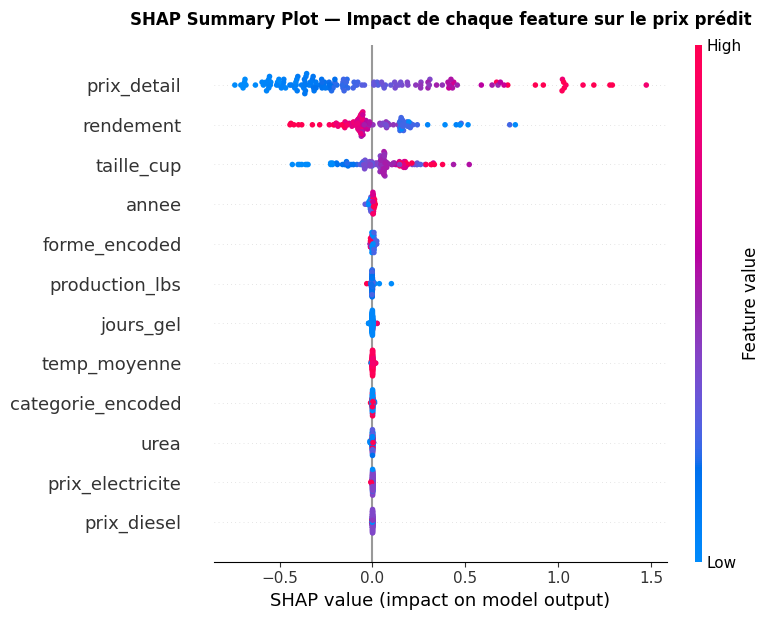

Graphique sauvegardé : ../models/shap_summary_plot.png


In [18]:
# ── GRAPHIQUE 1 : Summary plot — importance globale des features ──
# Ce graphique montre :
# - Sur l'axe X : la valeur SHAP (impact sur le prix prédit)
# - Chaque point = une observation du dataset de test
# - Couleur rouge = valeur élevée de la feature / bleu = valeur faible
# - Les features sont triées par importance globale (en haut = plus importante)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='dot',        # Chaque point = une observation
    show=False              # On contrôle l'affichage nous-mêmes
)
plt.title('SHAP Summary Plot — Impact de chaque feature sur le prix prédit',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../models/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : ../models/shap_summary_plot.png')

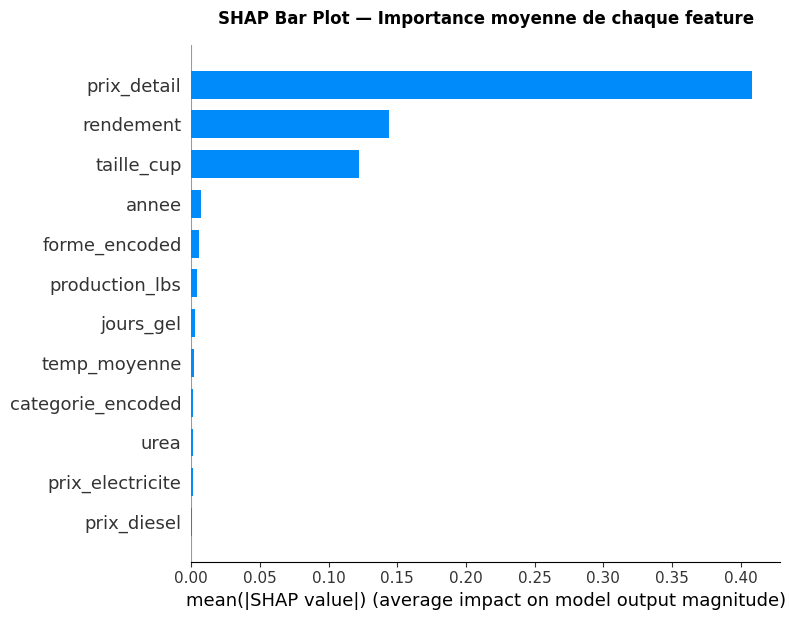

Graphique sauvegardé : ../models/shap_bar_plot.png


In [19]:
# ── GRAPHIQUE 2 : Bar plot — importance moyenne ──
# Version simplifiée : une seule barre par feature
# Montre l'importance moyenne de chaque feature sur TOUTES les prédictions
# Plus la barre est longue → plus la feature influence les prédictions en moyenne

plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',        # Une barre par feature
    show=False
)
plt.title('SHAP Bar Plot — Importance moyenne de chaque feature',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../models/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : ../models/shap_bar_plot.png')

Explication pour l'observation 0 :
  Prix réel   : 1.1603$
  Prix prédit : 1.2082$
  Erreur      : 0.0479$



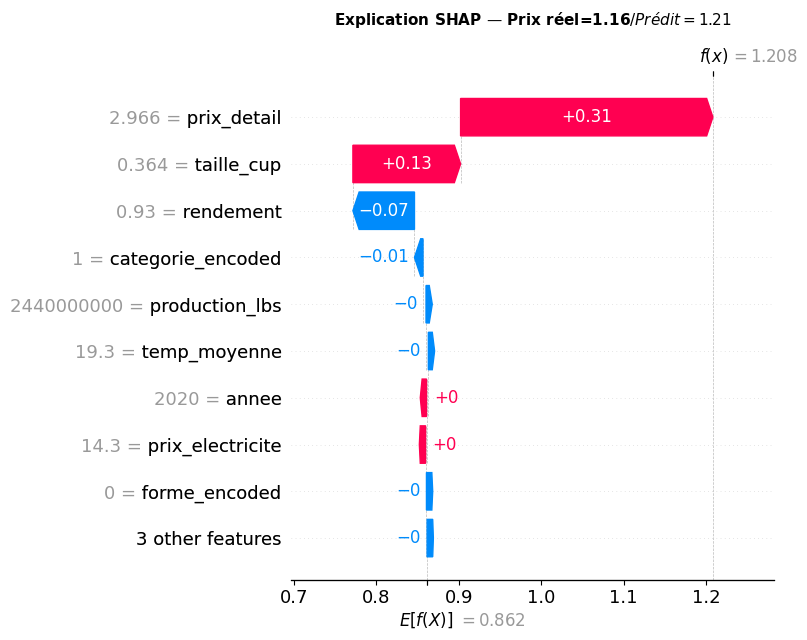

Graphique sauvegardé : ../models/shap_waterfall.png


In [20]:
# ── GRAPHIQUE 3 : Waterfall plot — explication d'une prédiction précise ──
# C'est le graphique le plus parlant pour le jury !
# Il montre EXACTEMENT pourquoi le modèle a prédit ce prix
# pour UNE observation précise

# On prend la première observation du test set
idx = 0
prix_reel  = y_test.iloc[idx]
prix_predit = y_pred[idx]

print(f'Explication pour l\'observation {idx} :')
print(f'  Prix réel   : {prix_reel:.4f}$')
print(f'  Prix prédit : {prix_predit:.4f}$')
print(f'  Erreur      : {abs(prix_reel - prix_predit):.4f}$')
print()

# Création de l'objet Explanation pour le waterfall plot
explanation = shap.Explanation(
    values     = shap_values[idx],              # Valeurs SHAP de cette observation
    base_values= explainer.expected_value,      # Valeur de base (prix moyen)
    data       = X_test.iloc[idx].values,       # Valeurs réelles des features
    feature_names = features_ok                 # Noms des features
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False)
plt.title(f'Explication SHAP — Prix réel={prix_reel:.2f}$ / Prédit={prix_predit:.2f}$',
          fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : ../models/shap_waterfall.png')

In [21]:
# ── TABLEAU : Top 5 features les plus importantes selon SHAP ──
# On calcule la moyenne des valeurs absolues des SHAP values
# pour chaque feature — c'est l'importance globale

importance_shap = pd.DataFrame({
    'feature'         : features_ok,
    'importance_shap' : np.abs(shap_values).mean(axis=0)  # Moyenne des |SHAP|
}).sort_values('importance_shap', ascending=False)

print('=' * 50)
print('TOP 5 FEATURES — IMPORTANCE SHAP')
print('=' * 50)
print(importance_shap.head(5).to_string(index=False))
print()
print('Interprétation :')
for _, row in importance_shap.head(3).iterrows():
    print(f"  {row['feature']:<20} influence le prix de ±{row['importance_shap']:.3f}$ en moyenne")

TOP 5 FEATURES — IMPORTANCE SHAP
      feature  importance_shap
  prix_detail         0.408335
    rendement         0.143826
   taille_cup         0.122315
        annee         0.007299
forme_encoded         0.005305

Interprétation :
  prix_detail          influence le prix de ±0.408$ en moyenne
  rendement            influence le prix de ±0.144$ en moyenne
  taille_cup           influence le prix de ±0.122$ en moyenne


## 6. Bilan C8 — Fichiers produits

In [23]:
# ── Récapitulatif de tous les fichiers produits ──
fichiers = [
    '../models/xgboost_fruits_legumes.pkl',
    '../models/features.json',
    '../models/shap_summary_plot.png',
    '../models/shap_bar_plot.png',
    '../models/shap_waterfall.png',
]

print('=' * 55)
print('BILAN C8 — FICHIERS PRODUITS')
print('=' * 55)
for f in fichiers:
    if os.path.exists(f):
        taille = os.path.getsize(f) / 1024
        print(f'   {f:<45} ({taille:.1f} Ko)')
    else:
        print(f'   {f:<45} (manquant)')

print()
print('Modèle XGBoost — Performance finale :')
print(f'  RMSE = {rmse:.4f} $/cup')
print(f'  MAE  = {mae:.4f} $/cup')
print(f'  R²   = {r2:.4f}')

BILAN C8 — FICHIERS PRODUITS
   ../models/xgboost_fruits_legumes.pkl          (278.6 Ko)
   ../models/features.json                       (0.4 Ko)
   ../models/shap_summary_plot.png               (99.7 Ko)
   ../models/shap_bar_plot.png                   (60.6 Ko)
   ../models/shap_waterfall.png                  (83.7 Ko)

Modèle XGBoost — Performance finale :
  RMSE = 0.0886 $/cup
  MAE  = 0.0451 $/cup
  R²   = 0.9755
